In [1]:
import torch as th
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('..')

import soft_tex.common.aux_plot

### Check time benchmark

In [2]:
results_path = '../soft_tex/script/time_benchmark.pth'

benchmark_dict  = th.load(results_path)

cpu_dict = benchmark_dict['cpu']
gpu_dict = benchmark_dict['gpu']

/tmp/ipykernel_25338/1506912555.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  benchmark_dict  = th.load(results_path)


In [3]:
units = list(cpu_dict['ParallelSoftSensingGRU'].keys())

# cpu
cpu_gru_mean_inference_times = [cpu_dict['ParallelSoftSensingGRU'][unit]['inference_time']['mean'] for unit in units]
cpu_gru_std_inference_times = [cpu_dict['ParallelSoftSensingGRU'][unit]['inference_time']['std'] for unit in units]

cpu_lstm_mean_inference_times = [cpu_dict['ParallelSoftSensingLSTM'][unit]['inference_time']['mean'] for unit in units]
cpu_lstm_std_inference_times = [cpu_dict['ParallelSoftSensingLSTM'][unit]['inference_time']['std'] for unit in units]

# gpu
gpu_gru_mean_inference_times = [gpu_dict['ParallelSoftSensingGRU'][unit]['inference_time']['mean'] for unit in units]
gpu_gru_std_inference_times = [gpu_dict['ParallelSoftSensingGRU'][unit]['inference_time']['std'] for unit in units]

gpu_lstm_mean_inference_times = [gpu_dict['ParallelSoftSensingLSTM'][unit]['inference_time']['mean'] for unit in units]
gpu_lstm_std_inference_times = [gpu_dict['ParallelSoftSensingLSTM'][unit]['inference_time']['std'] for unit in units]

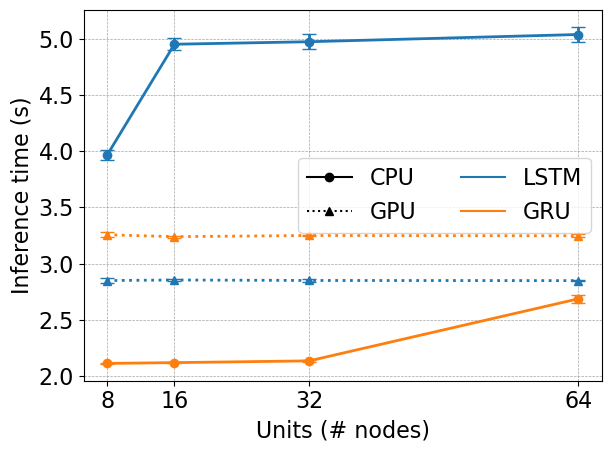

In [38]:
# cpu
plt.errorbar(units, cpu_lstm_mean_inference_times, yerr=cpu_lstm_std_inference_times, capsize=5, 
             color='C0', marker='o', linewidth=2, label='LSTM (CPU)')
plt.errorbar(units, cpu_gru_mean_inference_times, yerr=cpu_gru_std_inference_times, capsize=5, 
             color='C1', marker='o', linewidth=2, label='GRU (CPU)')

# gpu
plt.errorbar(units, gpu_lstm_mean_inference_times, yerr=gpu_lstm_std_inference_times, capsize=5, 
             color='C0', marker='^', linestyle=':', linewidth=2, label='LSTM (GPU)')
plt.errorbar(units, gpu_gru_mean_inference_times, yerr=gpu_gru_std_inference_times, capsize=5, 
             color='C1',marker='^', linestyle=':', linewidth=2, label='GRU (GPU)')

plt.xticks(units)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

# Custom legend handles
from matplotlib.lines import Line2D
cpu_handle = Line2D([0], [0], color='black', linestyle='-', marker='o', label='CPU')
gpu_handle = Line2D([0], [0], color='black', linestyle=':', marker='^', label='GPU')
lstm_handle = Line2D([0], [0], color='C0', label='LSTM')
gru_handle = Line2D([0], [0], color='C1', label='GRU')
plt.legend(handles=[cpu_handle, gpu_handle, lstm_handle, gru_handle], loc='best', ncols=2)

plt.xlabel("Units (# nodes)")
plt.ylabel("Inference time (s)")
plt.tight_layout()
plt.savefig(fname='../figures/time_benchmark.pdf', bbox_inches='tight', dpi=600)
plt.savefig(fname='../figures/time_benchmark.png', bbox_inches='tight', dpi=600)
plt.savefig(fname='../figures/time_benchmark.svg', bbox_inches='tight', dpi=600)
plt.show()

### Check model selection (learning curves)

In [39]:
results_path = '../trainings/model_selection.pth'

ms_results_dict  = th.load(results_path)

/tmp/ipykernel_25338/2333748953.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ms_results_dict  = th.load(results_path)


In [52]:
def get_average_learning_curve(results_dict, unit, model):
    histories = results_dict[model][unit]['histories']
    tr_loss_trials =  [history['training_losses'] for history in histories]
    vl_loss_trials =  [history['validation_losses'] for history in histories]
    epochs = np.arange(1, len(histories[0]['training_losses']) + 1, 1)

    avg_tr_loss_curve = np.mean(tr_loss_trials, axis=0)
    std_tr_loss_curve = np.std(tr_loss_trials, axis=0)

    avg_vl_loss_curve = np.mean(vl_loss_trials, axis=0)
    std_vl_loss_curve = np.std(vl_loss_trials, axis=0)
    
    return epochs, avg_tr_loss_curve, std_tr_loss_curve, avg_vl_loss_curve, std_vl_loss_curve

In [53]:
colors = ['blue', 'orange', 'green', 'red']
models = list(ms_results_dict.keys())
units = list(ms_results_dict[models[0]].keys())

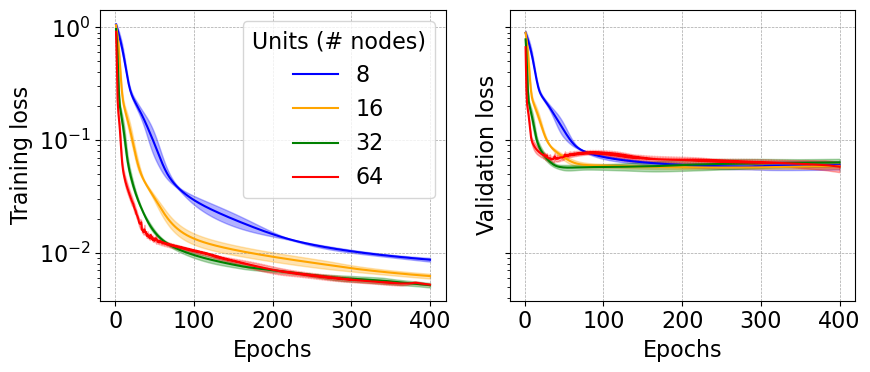

In [55]:
# GRU plots
model = 'ParallelSoftSensingGRU'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9,4), sharey=True)

for color, unit in zip(colors, units):
    epochs, avg_tr_loss_curve, std_tr_loss_curve, avg_vl_loss_curve, std_vl_loss_curve = get_average_learning_curve(ms_results_dict, unit, model)

    # training loss
    axes[0].plot(epochs, avg_tr_loss_curve, label='%d' % unit, color=color)
    axes[0].fill_between(x=epochs, y1=avg_tr_loss_curve - std_tr_loss_curve, y2=avg_tr_loss_curve + std_tr_loss_curve, color=color, alpha=0.3)
    axes[0].grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
    axes[0].set_ylabel('Training loss')
    axes[0].set_xlabel('Epochs')
    axes[0].legend(title='Units (# nodes)', loc='best', ncols=1)

    # validation loss
    axes[1].plot(epochs, avg_vl_loss_curve, label='%d' % unit, color=color)
    axes[1].fill_between(x=epochs, y1=avg_vl_loss_curve - std_vl_loss_curve, y2=avg_vl_loss_curve + std_vl_loss_curve, color=color, alpha=0.3)
    axes[1].grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
    axes[1].set_ylabel('Validation loss')
    axes[1].set_xlabel('Epochs')

plt.yscale('log')
plt.tight_layout()
plt.savefig(fname='../figures/GRU_model_selection.pdf', bbox_inches='tight', dpi=600)
plt.savefig(fname='../figures/GRU_model_selection.png', bbox_inches='tight', dpi=600)
plt.savefig(fname='../figures/GRU_model_selection.svg', bbox_inches='tight', dpi=600)
plt.show()

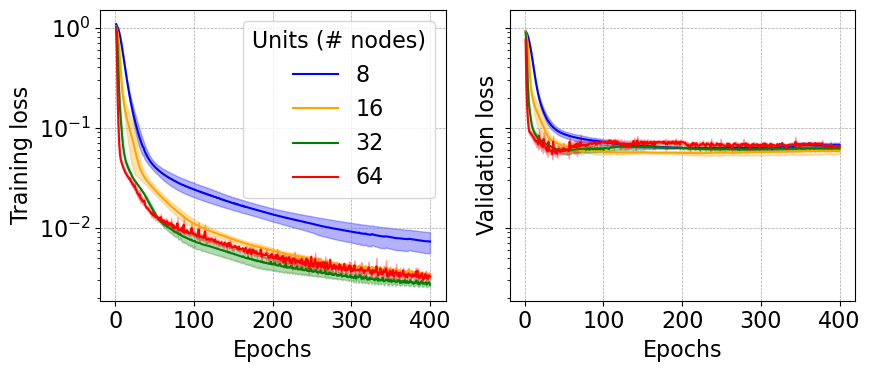

In [56]:
# LSTM plots
model = 'ParallelSoftSensingLSTM'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9,4), sharey=True)

for color, unit in zip(colors, units):
    epochs, avg_tr_loss_curve, std_tr_loss_curve, avg_vl_loss_curve, std_vl_loss_curve = get_average_learning_curve(ms_results_dict, unit, model)

    # training loss
    axes[0].plot(epochs, avg_tr_loss_curve, label='%d' % unit, color=color)
    axes[0].fill_between(x=epochs, y1=avg_tr_loss_curve - std_tr_loss_curve, y2=avg_tr_loss_curve + std_tr_loss_curve, color=color, alpha=0.3)
    axes[0].grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
    axes[0].set_ylabel('Training loss')
    axes[0].set_xlabel('Epochs')
    axes[0].legend(title='Units (# nodes)', loc='best', ncols=1)

    # validation loss
    axes[1].plot(epochs, avg_vl_loss_curve, label='%d' % unit, color=color)
    axes[1].fill_between(x=epochs, y1=avg_vl_loss_curve - std_vl_loss_curve, y2=avg_vl_loss_curve + std_vl_loss_curve, color=color, alpha=0.3)
    axes[1].grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
    axes[1].set_ylabel('Validation loss')
    axes[1].set_xlabel('Epochs')

plt.yscale('log')
plt.tight_layout()
plt.savefig(fname='../figures/LSTM_model_selection.pdf', bbox_inches='tight', dpi=600)
plt.savefig(fname='../figures/LSTM_model_selection.png', bbox_inches='tight', dpi=600)
plt.savefig(fname='../figures/LSTM_model_selection.svg', bbox_inches='tight', dpi=600)
plt.show()